# PatchTST Multivariate Forecasting — lon / lat / alt

This notebook trains the **official PatchTST** model from the paper  
[*A Time Series is Worth 64 Words: Long-term Forecasting with Transformers*](https://arxiv.org/abs/2211.14730)  
(ICLR 2023) on the `italy_flights_20k` dataset.

The model is loaded **directly** from the  
[HuggingFace `transformers` library](https://huggingface.co/docs/transformers/model_doc/patchtst):
```python
from transformers import PatchTSTConfig, PatchTSTForPrediction
```

- **Input (context):** 60 time-steps of `[lon, lat, alt]` (~10 min at 10 s spacing)
- **Output (forecast):** next 12 time-steps of `[lon, lat, alt]` (~2 min)
- Flights with fewer than 200 observations are dropped.
- Per-flight `StandardScaler` is applied before training (fit on train split only).
- Train / test split: 70 % / 30 % per flight.

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Official PatchTST from HuggingFace transformers ──────────────────────────
from transformers import PatchTSTConfig, PatchTSTForPrediction

print("PatchTSTForPrediction imported from HuggingFace transformers")
device = torch.device(
    "mps"  if torch.backends.mps.is_available()  else
    "cuda" if torch.cuda.is_available()           else
    "cpu"
)
print("Device:", device)

PatchTSTForPrediction imported from HuggingFace transformers
Device: mps


## 1. Hyper-parameters

In [8]:
# ── Data ─────────────────────────────────────────────────────────────────────
PARQUET_PATH = "../data/italy_flights_20k.parquet"
FEATURES     = ["lon", "lat", "alt"]
N_CHANNELS   = len(FEATURES)          # 3
MIN_LENGTH   = 200                    # drop flights shorter than this
TRAIN_FRAC   = 0.70

# ── Sequence lengths ──────────────────────────────────────────────────────────
INPUT_LEN    = 60                     # context window (seq_len)
OUTPUT_LEN   = 12                     # forecast horizon (pred_len)
WINDOW       = INPUT_LEN + OUTPUT_LEN

# ── PatchTST architecture ─────────────────────────────────────────────────────
PATCH_LEN    = 8                      # tokens cover 8 time-steps each
PATCH_STRIDE = 4                      # stride between patches (overlap)
D_MODEL      = 128
N_HEADS      = 4
N_LAYERS     = 2
FFN_DIM      = 256
HEAD_DROPOUT = 0.1
ATTN_DROPOUT = 0.1

# ── Training ──────────────────────────────────────────────────────────────────
N_EPOCHS     = 3
BATCH_SIZE   = 64
LR           = 1e-3

SEED         = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## 2. Load data

In [3]:
df = pd.read_parquet(PARQUET_PATH)
df["datetime"] = pd.to_datetime(df["timestamp"], unit="s")

print(f"Total rows    : {len(df):,}")
print(f"Unique flights: {df['track_id'].nunique():,}")
df.head()

Total rows    : 2,493,533
Unique flights: 13,919


,track_id,lon,lat,alt,timestamp,datetime
0,000001_2021-01-25,36.204828,31.774975,4732.02,1611588050,2021-01-25 15:20:50
1,000001_2021-01-25,36.215552,31.771251,4792.98,1611588060,2021-01-25 15:21:00
2,000001_2021-01-25,36.225934,31.767666,4853.94,1611588070,2021-01-25 15:21:10
3,000001_2021-01-25,36.236920,31.763942,4922.52,1611588080,2021-01-25 15:21:20
4,000001_2021-01-25,36.247128,31.760513,4998.72,1611588090,2021-01-25 15:21:30


## 3. Build per-flight arrays

In [4]:
flights_data = []   # list of numpy arrays [T, 3]
skipped      = 0

for track_id, g in df.groupby("track_id"):
    g = g.sort_values("datetime").drop_duplicates(subset="datetime")

    if len(g) < MIN_LENGTH:
        skipped += 1
        continue

    vals = g[FEATURES].values.astype(np.float32)   # [T, 3]
    if np.isnan(vals).any():
        skipped += 1
        continue

    flights_data.append(vals)

print(f"Kept: {len(flights_data):,} flights  |  Skipped: {skipped:,}")

Kept: 5,828 flights  |  Skipped: 8,091


## 4. Scale & split (70 / 30 per flight)

In [5]:
train_flights = []   # list of scaled numpy arrays
test_flights  = []
scalers       = []

for vals in flights_data:
    split = int(len(vals) * TRAIN_FRAC)

    scaler    = StandardScaler()
    train_sc  = scaler.fit_transform(vals[:split])
    test_sc   = scaler.transform(vals[split:])

    train_flights.append(train_sc.astype(np.float32))
    test_flights.append(test_sc.astype(np.float32))
    scalers.append(scaler)

print(f"Train flights: {len(train_flights):,}  |  Test flights: {len(test_flights):,}")

Train flights: 5,828  |  Test flights: 5,828


## 5. Build sliding-window dataset

HuggingFace PatchTST expects tensors of shape **`[B, T, C]`** —
batch × time-steps × channels — which is the standard HF time-series layout.

In [6]:
def build_windows(flights):
    """Return (X [N, INPUT_LEN, C], Y [N, OUTPUT_LEN, C]) tensors."""
    xs, ys = [], []
    for vals in flights:
        T = len(vals)
        for start in range(T - WINDOW + 1):
            end_in  = start + INPUT_LEN
            end_out = start + WINDOW
            xs.append(vals[start:end_in])    # [INPUT_LEN, 3]
            ys.append(vals[end_in:end_out])  # [OUTPUT_LEN, 3]
    X = torch.tensor(np.stack(xs), dtype=torch.float32)
    Y = torch.tensor(np.stack(ys), dtype=torch.float32)
    return X, Y

print("Building training windows...")
X_train, Y_train = build_windows(train_flights)
print(f"Train windows: {X_train.shape[0]:,}   X={X_train.shape}  Y={Y_train.shape}")

print("Building test windows...")
X_test,  Y_test  = build_windows(test_flights)
print(f"Test  windows: {X_test.shape[0]:,}   X={X_test.shape}  Y={Y_test.shape}")

Building training windows...
Train windows: 760,038   X=torch.Size([760038, 60, 3])  Y=torch.Size([760038, 12, 3])
Building test windows...
Test  windows: 100,103   X=torch.Size([100103, 60, 3])  Y=torch.Size([100103, 12, 3])


## 6. Instantiate PatchTST (official HuggingFace)

Key config choices:
| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `context_length` | 60 | INPUT_LEN |
| `prediction_length` | 12 | OUTPUT_LEN |
| `num_input_channels` | 3 | lon, lat, alt |
| `patch_length` | 8 | sub-sequence token length |
| `patch_stride` | 4 | stride → overlapping patches |
| `loss` | `"mse"` | regression objective |

In [9]:
config = PatchTSTConfig(
    num_input_channels  = N_CHANNELS,
    context_length      = INPUT_LEN,
    prediction_length   = OUTPUT_LEN,
    patch_length        = PATCH_LEN,
    patch_stride        = PATCH_STRIDE,
    d_model             = D_MODEL,
    num_attention_heads = N_HEADS,
    num_hidden_layers   = N_LAYERS,
    ffn_dim             = FFN_DIM,
    head_dropout        = HEAD_DROPOUT,
    attention_dropout   = ATTN_DROPOUT,
    loss                = "mse",
    scaling             = None,      # we handle scaling ourselves
)

model = PatchTSTForPrediction(config).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"PatchTST trainable parameters: {n_params:,}")
print(config)

PatchTST trainable parameters: 267,660
PatchTSTConfig {
  "activation_function": "gelu",
  "attention_dropout": 0.1,
  "bias": true,
  "channel_attention": false,
  "channel_consistent_masking": false,
  "context_length": 60,
  "d_model": 128,
  "distribution_output": "student_t",
  "do_mask_input": null,
  "ff_dropout": 0.0,
  "ffn_dim": 256,
  "head_dropout": 0.1,
  "init_std": 0.02,
  "loss": "mse",
  "mask_type": "random",
  "mask_value": 0,
  "model_type": "patchtst",
  "norm_eps": 1e-05,
  "norm_type": "batchnorm",
  "num_attention_heads": 4,
  "num_forecast_mask_patches": [
    2
  ],
  "num_hidden_layers": 2,
  "num_input_channels": 3,
  "num_parallel_samples": 100,
  "num_targets": 1,
  "output_range": null,
  "patch_length": 8,
  "patch_stride": 4,
  "path_dropout": 0.0,
  "pooling_type": "mean",
  "positional_dropout": 0.0,
  "positional_encoding_type": "sincos",
  "pre_norm": true,
  "prediction_length": 12,
  "random_mask_ratio": 0.5,
  "scaling": null,
  "share_embedding"

## 7. Train the model

We pass `future_values=Y` during training so the HF model can compute
the MSE loss internally (`output.loss`).  
The model architecture follows channel-independence (CI): each of the 3
channels is processed independently through the same Transformer.

In [19]:
train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size = BATCH_SIZE,
    shuffle    = True,
)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

model.train()
for epoch in range(1, N_EPOCHS + 1):
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)   # [B, INPUT_LEN, 3]
        yb = yb.to(device)   # [B, OUTPUT_LEN, 3]

        out  = model(past_values=xb, future_values=yb)
        loss = out.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * xb.size(0)

    avg = epoch_loss / len(X_train)
    print(f"Epoch {epoch:02d}/{N_EPOCHS}  train_loss={avg:.6f}")

print("Training complete.")

Epoch 01/3  train_loss=0.159976
Epoch 02/3  train_loss=0.153400
Epoch 03/3  train_loss=0.150128
Training complete.


## 8. Evaluate on test set

In [20]:
test_loader = DataLoader(
    TensorDataset(X_test, Y_test),
    batch_size = 512,
    shuffle    = False,
)

model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb  = xb.to(device)
        out = model(past_values=xb)              # inference — no future_values
        all_preds.append(out.prediction_outputs.cpu())
        all_true.append(yb)

all_preds = torch.cat(all_preds)   # [N, OUTPUT_LEN, 3]
all_true  = torch.cat(all_true)

mse_val = ((all_preds - all_true) ** 2).mean().item()
mae_val = (all_preds - all_true).abs().mean().item()

print(f"Test MSE : {mse_val:.6f}")
print(f"Test MAE : {mae_val:.6f}")

Test MSE : 230771.875000
Test MAE : 40.069473


## 9. Per-feature time-series plot

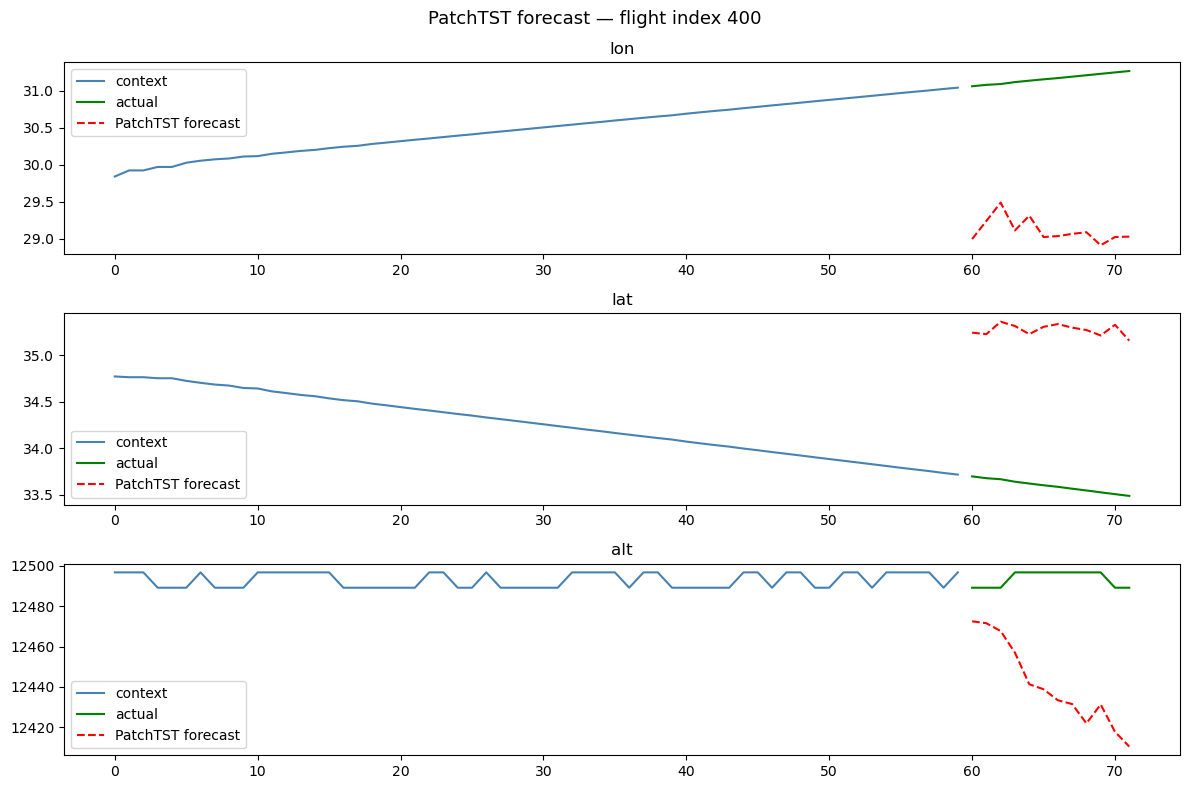

In [21]:
SAMPLE_IDX = 400   # change to inspect a different flight

test_vals = test_flights[SAMPLE_IDX]
scaler    = scalers[SAMPLE_IDX]

ctx_sc  = test_vals[:INPUT_LEN]                        # [INPUT_LEN, 3]
act_sc  = test_vals[INPUT_LEN:INPUT_LEN + OUTPUT_LEN]  # [OUTPUT_LEN, 3]

if len(act_sc) < OUTPUT_LEN:
    raise ValueError("Flight too short — try a different SAMPLE_IDX.")

xb = torch.tensor(ctx_sc[np.newaxis], dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    out    = model(past_values=xb)
    fct_sc = out.prediction_outputs.cpu().numpy()[0]   # [OUTPUT_LEN, 3]

# Inverse-transform to original units
ctx_orig = scaler.inverse_transform(ctx_sc)
act_orig = scaler.inverse_transform(act_sc)
fct_orig = scaler.inverse_transform(fct_sc)

ctx_x = np.arange(INPUT_LEN)
act_x = np.arange(INPUT_LEN, INPUT_LEN + OUTPUT_LEN)

feature_names = ["lon", "lat", "alt"]
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)

for i, (ax, feat) in enumerate(zip(axes, feature_names)):
    ax.plot(ctx_x, ctx_orig[:, i], color="steelblue", label="context")
    ax.plot(act_x, act_orig[:, i], color="green",     label="actual")
    ax.plot(act_x, fct_orig[:, i], color="red", linestyle="--",
            label="PatchTST forecast")
    ax.set_title(feat)
    ax.legend()

plt.suptitle(f"PatchTST forecast — flight index {SAMPLE_IDX}", fontsize=13)
plt.tight_layout()
plt.show()

## 10. 2-D trajectory plot (lon vs lat)

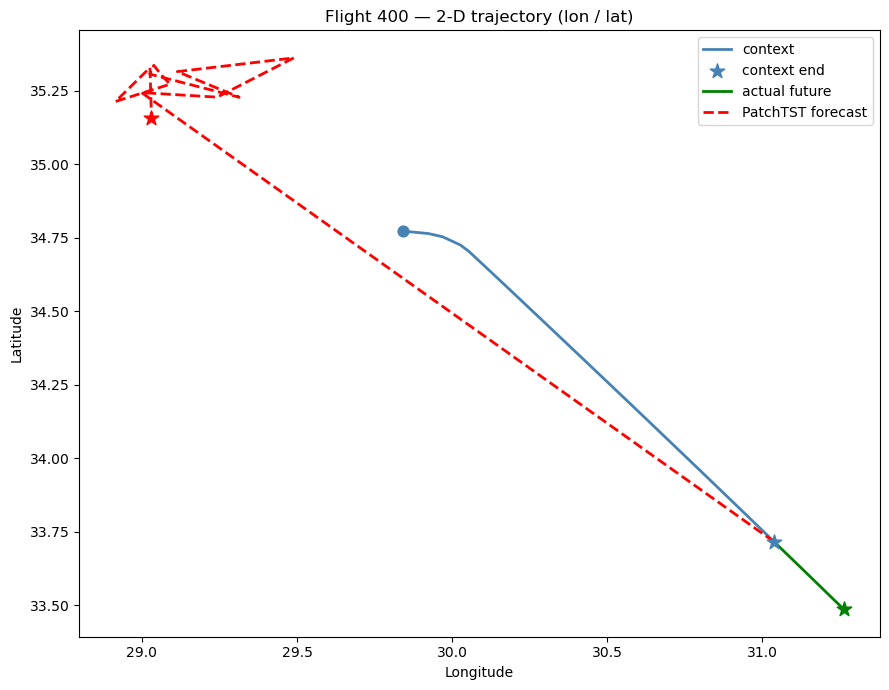

In [22]:
fig, ax = plt.subplots(figsize=(9, 7))

# Context path
ax.plot(ctx_orig[:, 0], ctx_orig[:, 1],
        color="steelblue", linewidth=2, label="context")
ax.scatter(ctx_orig[0,  0], ctx_orig[0,  1],
           color="steelblue", s=60, zorder=5)
ax.scatter(ctx_orig[-1, 0], ctx_orig[-1, 1],
           color="steelblue", s=120, marker="*", zorder=5, label="context end")

# Actual future
ax.plot(
    [ctx_orig[-1, 0]] + list(act_orig[:, 0]),
    [ctx_orig[-1, 1]] + list(act_orig[:, 1]),
    color="green", linewidth=2, label="actual future"
)
ax.scatter(act_orig[-1, 0], act_orig[-1, 1],
           color="green", s=120, marker="*", zorder=5)

# Forecast
ax.plot(
    [ctx_orig[-1, 0]] + list(fct_orig[:, 0]),
    [ctx_orig[-1, 1]] + list(fct_orig[:, 1]),
    color="red", linewidth=2, linestyle="--", label="PatchTST forecast"
)
ax.scatter(fct_orig[-1, 0], fct_orig[-1, 1],
           color="red", s=120, marker="*", zorder=5)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Flight {SAMPLE_IDX} — 2-D trajectory (lon / lat)")
ax.legend()
plt.tight_layout()
plt.show()

## 11. 3-D trajectory plot (lon, lat, alt)

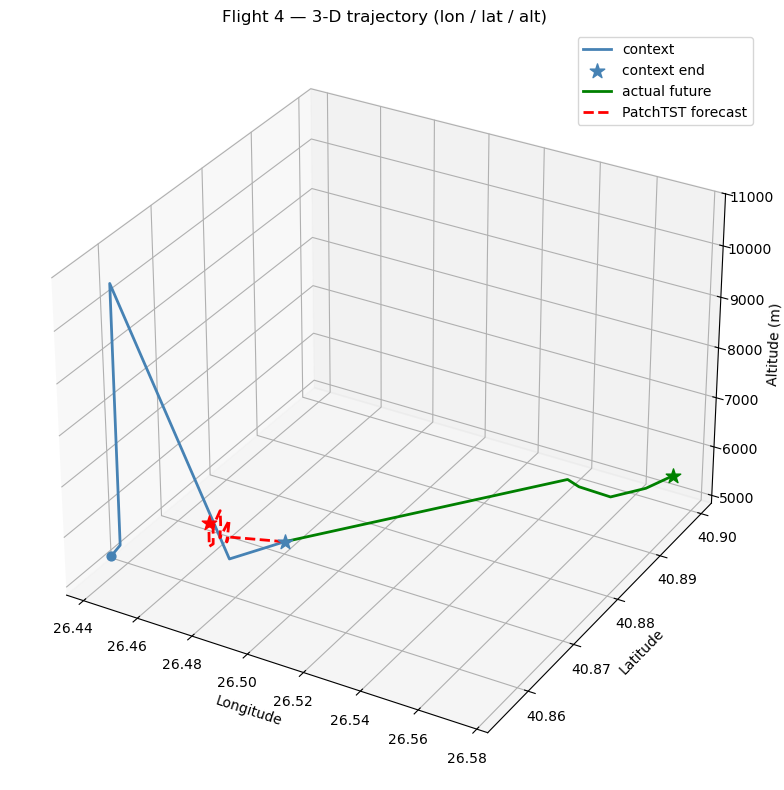

In [14]:
fig = plt.figure(figsize=(11, 8))
ax3 = fig.add_subplot(111, projection="3d")

# Context path
ax3.plot(ctx_orig[:, 0], ctx_orig[:, 1], ctx_orig[:, 2],
         color="steelblue", linewidth=2, label="context")
ax3.scatter(*ctx_orig[0],  color="steelblue", s=40,  zorder=5)
ax3.scatter(*ctx_orig[-1], color="steelblue", s=120,
            marker="*", zorder=5, label="context end")

# Actual future
bridge_act = np.vstack([ctx_orig[-1:], act_orig])
ax3.plot(bridge_act[:, 0], bridge_act[:, 1], bridge_act[:, 2],
         color="green", linewidth=2, label="actual future")
ax3.scatter(*act_orig[-1], color="green", s=120, marker="*", zorder=5)

# Forecast
bridge_fct = np.vstack([ctx_orig[-1:], fct_orig])
ax3.plot(bridge_fct[:, 0], bridge_fct[:, 1], bridge_fct[:, 2],
         color="red", linewidth=2, linestyle="--", label="PatchTST forecast")
ax3.scatter(*fct_orig[-1], color="red", s=120, marker="*", zorder=5)

ax3.set_xlabel("Longitude")
ax3.set_ylabel("Latitude")
ax3.set_zlabel("Altitude (m)")
ax3.set_title(f"Flight {SAMPLE_IDX} — 3-D trajectory (lon / lat / alt)")
ax3.legend()
plt.tight_layout()
plt.show()

## 12. Save model weights

In [23]:
import os
os.makedirs('saved_models/patchtst', exist_ok=True)
model.save_pretrained('saved_models/patchtst/')
print('Model saved to saved_models/patchtst/')


Model saved to saved_models/patchtst/
